In [1]:
import pandas as pd
from lib.graph_plot import plot_pairs

In [2]:
# set the target class
TARGET = 'CRS'

# Protein concentration threshold
PROTEIN_CONC_THRESHOLD = 0.15  # 15% difference

# Pairing Process

In [3]:
# loading the cleaned data
df = pd.read_csv('input/cleaned.csv', index_col=0)
df

,2A_BIRC3,BIRC3_BIRC3,FYB_BIRC3,LCK_BIRC3,NCK_BIRC3,PKCt_BIRC3,TRAF1_BIRC3,TRAF2_BIRC3,VAV1_BIRC3,2A_CD28,...,TRAF1_ZAP70,TRAF2_ZAP70,VAV1_ZAP70,ZAP70_ZAP70,cd4v8,protein conc,CRS,stim type,pair num,control
CAR_19_447,94.697900,159.000467,111.025340,95.692668,102.449484,116.653537,59.761530,91.384325,119.192217,94.043909,...,104.046637,100.633391,89.477148,61.399937,4.0,1.740,1.0,19,NaN,0
CAR_19_464,105.715935,100.395341,95.103711,106.064396,95.958365,97.413419,81.353148,99.321770,106.735452,98.773677,...,103.222083,95.524683,104.400218,68.545724,4.0,2.230,1.0,19,NaN,0
CAR_19_464_1,106.692161,75.011666,93.534483,106.956522,97.537879,93.095238,72.747554,104.911591,92.900609,91.084337,...,102.412869,96.194503,134.579439,58.124373,4.0,2.230,1.0,19,NaN,0
CAR_19_464_2,106.009615,110.487201,92.600897,108.830022,91.312741,98.976982,102.555629,96.237624,132.124352,105.475040,...,106.779661,89.086860,96.259352,56.084337,4.0,2.210,1.0,19,NaN,0
CAR_19_467,86.282699,95.343400,93.226090,90.969214,106.721199,97.303476,102.080979,100.673954,102.839009,80.721294,...,94.883577,96.859977,101.986777,46.855297,4.0,2.680,1.0,19,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
control_CAR_19_852,111.796468,105.955794,95.394818,107.496860,95.016724,105.687129,98.343684,104.705977,97.546122,72.549735,...,96.208360,105.259298,107.314708,55.092140,8.0,2.126,0.0,19,9005,1
control_CAR_19_452,104.197314,98.356982,94.065122,93.456438,95.244350,100.000000,100.432041,94.211816,103.147788,85.979753,...,98.985525,99.500599,92.356238,84.500164,4.0,1.680,0.0,19,9001,1
control_CAR_19_494,89.100974,98.914132,110.917955,102.012981,96.436904,107.171480,100.569777,105.949552,95.195885,90.275297,...,96.880191,102.726253,90.829984,48.357894,4.0,1.500,0.0,19,9001,1
control_CAR_19_486,104.094651,97.836507,103.976595,103.743390,99.438188,96.003489,103.420011,104.076610,89.802380,99.813703,...,93.767305,100.664951,105.337734,66.866639,4.0,3.700,0.0,19,9002,1


Some data were paired experimentally so we dont need to run the auto pairing algorithm on them

In [4]:
# pull out the "already paired" data
already_paired_df = df[df['pair num'].notnull()]
df = df[df['pair num'].isnull()]

already_paired_df

,2A_BIRC3,BIRC3_BIRC3,FYB_BIRC3,LCK_BIRC3,NCK_BIRC3,PKCt_BIRC3,TRAF1_BIRC3,TRAF2_BIRC3,VAV1_BIRC3,2A_CD28,...,TRAF1_ZAP70,TRAF2_ZAP70,VAV1_ZAP70,ZAP70_ZAP70,cd4v8,protein conc,CRS,stim type,pair num,control
OR_US_1,140.123513,104.309708,147.401096,122.071515,112.237066,106.985702,104.596598,140.555680,126.851136,269.926369,...,104.155719,148.789332,128.213229,1074.678465,4.0,2.600,0.0,NaN,U1,0
OR_US_2,139.338783,100.038927,151.050314,127.692394,106.418065,110.522039,100.744792,148.240737,132.103948,237.985322,...,105.820906,148.253493,130.523874,955.714456,4.0,2.000,0.0,NaN,U2,0
OR_US_3,142.987793,107.417446,153.231292,120.435940,113.825218,105.319573,106.120020,141.503082,119.676657,296.333253,...,104.032952,150.507823,130.689419,904.081385,4.0,1.900,0.0,NaN,U3,0
OR_US_4,140.782992,102.021659,152.207431,131.686742,113.264489,111.696622,100.561761,149.255105,125.891945,295.954319,...,106.825000,151.341511,124.775217,809.776856,4.0,2.000,0.0,NaN,U4,0
OR_US_5,143.843327,96.722079,150.495478,127.142897,106.876936,107.913904,108.834624,149.506815,119.678488,225.583882,...,103.200553,152.950116,125.980493,850.486981,4.0,2.000,0.0,NaN,U5,0
CRS_US_1,138.513352,93.858233,161.919904,131.326481,107.688259,104.032468,102.384353,151.679921,120.051235,267.562208,...,104.601164,152.717379,126.353685,736.174354,4.0,2.600,1.0,NaN,U1,0
CRS_US_2,142.220038,106.586129,144.737106,119.946555,112.562186,110.522039,103.933472,142.460152,121.866658,246.147866,...,101.539991,151.818909,128.777524,807.466242,4.0,2.000,1.0,NaN,U2,0
CRS_US_3,142.114448,96.917902,154.012106,129.609289,110.685586,104.849788,108.683718,146.638689,144.916605,243.279101,...,104.805727,147.544791,127.617223,766.422604,4.0,1.900,1.0,NaN,U3,0
CRS_US_4,141.828298,99.152734,150.285262,131.132467,111.986445,105.506861,103.556469,152.988290,127.993343,251.232299,...,103.853683,148.126490,129.896037,1018.430540,4.0,2.000,1.0,NaN,U4,0
CRS_US_5,149.884563,103.813868,160.556735,123.126581,113.422447,105.855565,102.442332,149.193192,134.829172,305.541690,...,106.307165,152.146758,128.049208,817.218125,4.0,2.000,1.0,NaN,U5,0


In [5]:
# separate our two class in to two
control_df = df[df[TARGET] == 0]
positive_df = df[df[TARGET] == 1]

print(f'Control Count: {control_df.shape[0]}')
print(f'{TARGET} Count: {positive_df.shape[0]}')

Control Count: 36
CRS Count: 39


In [6]:
# Create empty dictionary
CD_cells_group = {}
# Iterate through stimulation types
for stim in ['19', 'N3', 'KP']:
    for cd_type, cd_value in [('cd4', 4), ('cd8', 8)]:
        # control groups
        crs_group = control_df[(control_df['stim type'] == stim) & (control_df['cd4v8'] == cd_value)]
        CD_cells_group[f"control_{cd_type}_{stim}"] = crs_group

        # positive group
        or_group = positive_df[(positive_df['stim type'] == stim) & (positive_df['cd4v8'] == cd_value)]
        CD_cells_group[f"{TARGET}_{cd_type}_{stim}"] = or_group

print("Found the groups")
print(CD_cells_group.keys())

Found the groups
dict_keys(['control_cd4_19', 'CRS_cd4_19', 'control_cd8_19', 'CRS_cd8_19', 'control_cd4_N3', 'CRS_cd4_N3', 'control_cd8_N3', 'CRS_cd8_N3', 'control_cd4_KP', 'CRS_cd4_KP', 'control_cd8_KP', 'CRS_cd8_KP'])


In [7]:
from find_protein_conc_pair import find_protein_conc_pair

# Initialize pair tracking
paired_df = pd.DataFrame()
current_pair_num = 0

# iterate through the stim groups and cell types
for stim in ['19', 'N3', 'KP']:
    for cd_type in ['cd4', 'cd8']:
        # Get CRS and OR dataframes for this stimulation and cell type
        crs_key = f"{TARGET}_{cd_type}_{stim}"
        or_key = f"control_{cd_type}_{stim}"

        # Skip if either group is empty
        if CD_cells_group[crs_key].empty or CD_cells_group[or_key].empty:
            print(f"Skipping {crs_key} and {or_key} - one or both are empty")
            continue

        print(f"Finding pairs for {stim} {cd_type.upper()}")
        paired_df, current_pair_num = find_protein_conc_pair(
            CD_cells_group[crs_key],
            CD_cells_group[or_key],
            threshold=PROTEIN_CONC_THRESHOLD,
            paired_df=paired_df,
            start_pair_num=current_pair_num
        )

print('Found a total of {} pairs'.format(current_pair_num))

Finding pairs for 19 CD4
Finding pairs for 19 CD8
Finding pairs for N3 CD4
Finding pairs for N3 CD8
Finding pairs for KP CD4
Finding pairs for KP CD8
Found a total of 19 pairs


In [8]:
# add the already_paired_df to the paired_df
paired_df = pd.concat([paired_df, already_paired_df], axis=0)
experimental_pair_df = paired_df[paired_df['control'] == 0]

# make sure its all in the same format make them all strings
paired_df['pair num'] = paired_df['pair num'].astype(str)
experimental_pair_df['pair num'] = experimental_pair_df['pair num'].astype(str)

experimental_pair_df

C:\Users\guyok\AppData\Local\Temp\ipykernel_20244\3234575453.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  experimental_pair_df['pair num'] = experimental_pair_df['pair num'].astype(str)


,2A_BIRC3,BIRC3_BIRC3,FYB_BIRC3,LCK_BIRC3,NCK_BIRC3,PKCt_BIRC3,TRAF1_BIRC3,TRAF2_BIRC3,VAV1_BIRC3,2A_CD28,...,TRAF1_ZAP70,TRAF2_ZAP70,VAV1_ZAP70,ZAP70_ZAP70,cd4v8,protein conc,CRS,stim type,pair num,control
CAR_19_447,94.697900,159.000467,111.025340,95.692668,102.449484,116.653537,59.761530,91.384325,119.192217,94.043909,...,104.046637,100.633391,89.477148,61.399937,4.0,1.7400,1.0,19,0,0
CAR_19_452,104.197314,98.356982,94.065122,93.456438,95.244350,100.000000,100.432041,94.211816,103.147788,85.979753,...,98.985525,99.500599,92.356238,84.500164,4.0,1.6800,0.0,19,0,0
CAR_19_474,104.683625,105.710126,101.073675,102.917878,109.875469,103.218313,100.449846,98.453014,100.671194,90.102944,...,101.132333,100.221157,90.476043,46.290540,4.0,3.3910,1.0,19,1,0
CAR_19_411,99.256191,101.863501,98.148051,104.806283,104.904170,101.703217,97.475530,98.223413,91.742383,100.000000,...,95.454623,98.174269,97.186781,61.132548,4.0,3.6000,0.0,19,1,0
CAR_19_847,102.771140,102.800192,113.301085,90.379008,102.434929,94.267292,53.379440,87.746888,86.603657,82.339738,...,95.711830,102.320206,104.235158,73.324026,8.0,0.8000,1.0,19,2,0
CAR_19_888,102.892152,96.662249,97.061463,98.684239,94.021608,106.113858,100.407760,111.097311,120.546654,89.936543,...,95.887047,101.252198,100.652867,50.930056,8.0,0.7930,0.0,19,2,0
CAR_19_867,108.251635,99.475774,106.443084,99.346731,92.084862,111.008992,96.323311,91.834177,88.062144,66.170994,...,98.760054,96.857850,90.232314,83.041696,8.0,2.3185,1.0,19,3,0
CAR_19_886,92.828291,97.434308,107.994411,105.234578,96.901243,96.185858,101.631084,111.677312,100.000000,69.948905,...,98.639907,105.848786,108.448830,49.987138,8.0,2.4000,0.0,19,3,0
CAR_19_874,96.711666,101.360706,99.042244,97.714307,96.847584,104.215703,100.761782,104.378853,84.947378,80.081658,...,102.023107,101.131170,100.733998,250.423947,8.0,3.1600,1.0,19,4,0
CAR_19_803,97.692306,98.858415,91.362179,93.332306,105.852304,107.663819,95.672534,92.108654,111.808614,93.581207,...,103.063063,96.806586,109.371366,63.614701,8.0,3.3670,0.0,19,4,0


In [9]:
# create a "pair dict" the key is the experimental and the value is the control/negative class index
pair_dict = {}

# group by the pair num
grouped = paired_df.groupby('pair num')
# for each group get the positive and control
for name, group in grouped:
    # get the two groups
    try:
        control_df = group[group[TARGET] == 0].index[0]
        positive_df = group[group[TARGET] == 1].index[0]

    except IndexError:
        # no control or positive is likely the control group so we can just pick the first one and second one
        control_df = group.index[0]
        positive_df = group.index[1]

    # add to the dict
    pair_dict[positive_df] = control_df

pair_dict

{'CAR_19_447': 'CAR_19_452',
 'CAR_19_474': 'CAR_19_411',
 'CAR_N3_874_1': 'CAR_N3_892',
 'CAR_N3_874_3': 'CAR_N3_886',
 'CAR_KP_447': 'CAR_KP_452',
 'CAR_KP_847': 'CAR_KP_888',
 'CAR_KP_867': 'CAR_KP_894',
 'CAR_KP_874': 'CAR_KP_892',
 'CAR_KP_874_1': 'CAR_KP_886',
 'CAR_KP_874_2': 'CAR_KP_846',
 'CAR_KP_874_3': 'CAR_KP_803',
 'CAR_19_847': 'CAR_19_888',
 'CAR_19_867': 'CAR_19_886',
 'CAR_19_874': 'CAR_19_803',
 'CAR_19_874_1': 'CAR_19_892',
 'CAR_19_874_2': 'CAR_19_846',
 'CAR_19_890': 'CAR_19_811',
 'CAR_N3_867': 'CAR_N3_852',
 'CAR_N3_874': 'CAR_N3_846',
 'control_CAR_19_494': 'control_CAR_19_452',
 'control_CAR_19_411': 'control_CAR_19_486',
 'control_CAR_19_846': 'control_CAR_19_811',
 'control_CAR_19_892': 'control_CAR_19_803',
 'control_CAR_19_852': 'control_CAR_19_894',
 'control_CAR_N3_411': 'control_CAR_N3_486',
 'control_CAR_N3_846': 'control_CAR_N3_892',
 'control_CAR_N3_894': 'control_CAR_N3_886',
 'control_CAR_KP_494': 'control_CAR_KP_452',
 'control_CAR_KP_411': 'contro

# Paired Visualization

In [10]:
# find the index where CD4v8 is 4 and 8
cd4_index = experimental_pair_df[experimental_pair_df['cd4v8'] == 4].index
cd8_index = experimental_pair_df[experimental_pair_df['cd4v8'] == 8].index

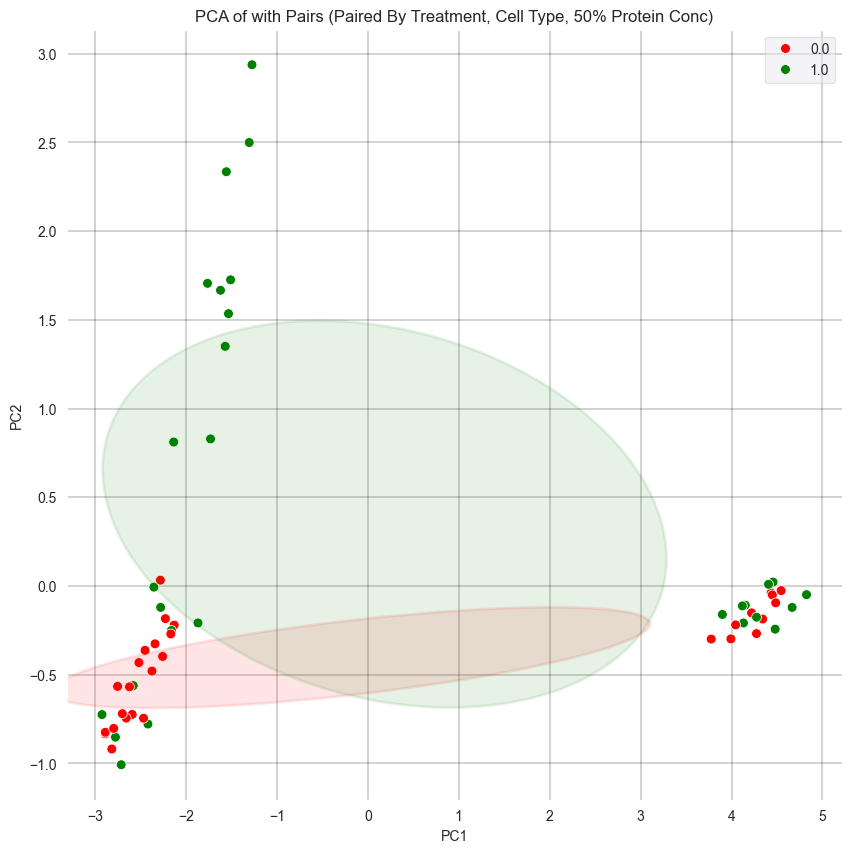

In [11]:
# plot the pca with the pairs
plt = plot_pairs(experimental_pair_df,
           pair_dict,
           target=TARGET,
           title="PCA of with Pairs (Paired By Treatment, Cell Type, 50% Protein Conc)")

plt.savefig('output/PCA_prenormalized_all.svg', dpi=300)

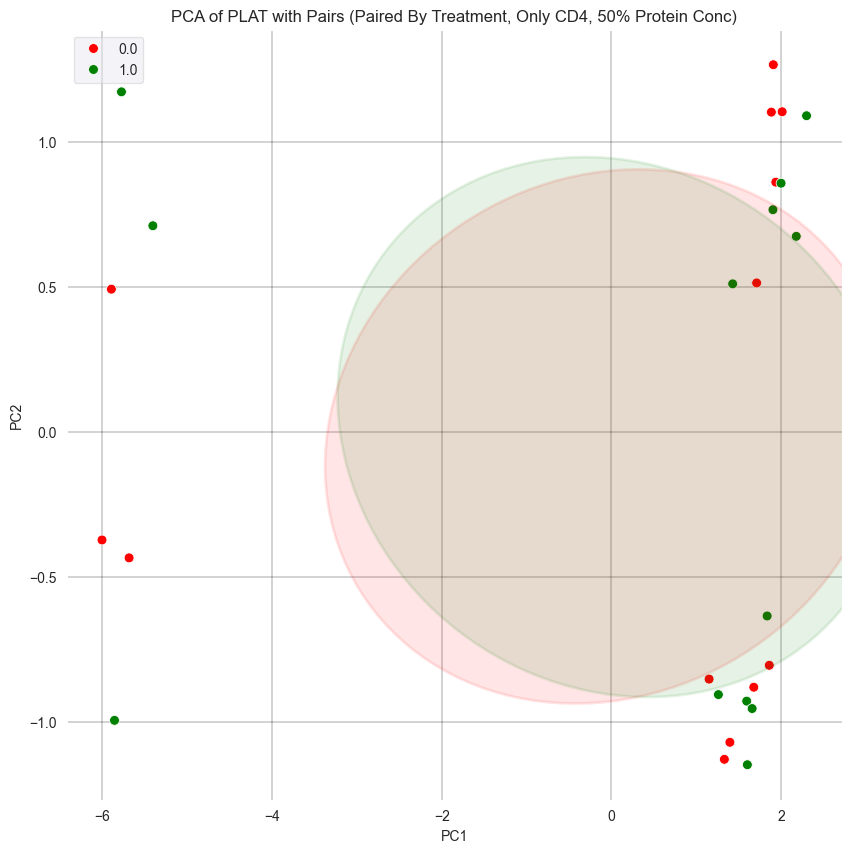

In [12]:
# Show CD4 Graph
cd4_df = experimental_pair_df.loc[cd4_index]

# get a the pair that exist in the CD8 index
cd4_pair_dict = {}
for key, value in pair_dict.items():
    if key in cd4_index and value in cd4_index:
        cd4_pair_dict[key] = value

plt = plot_pairs(cd4_df,
           cd4_pair_dict,
           target=TARGET,
           title="PCA of PLAT with Pairs (Paired By Treatment, Only CD4, 50% Protein Conc)"
           )

plt.savefig('output/PCA_prenormalized_CD4.svg', dpi=300)

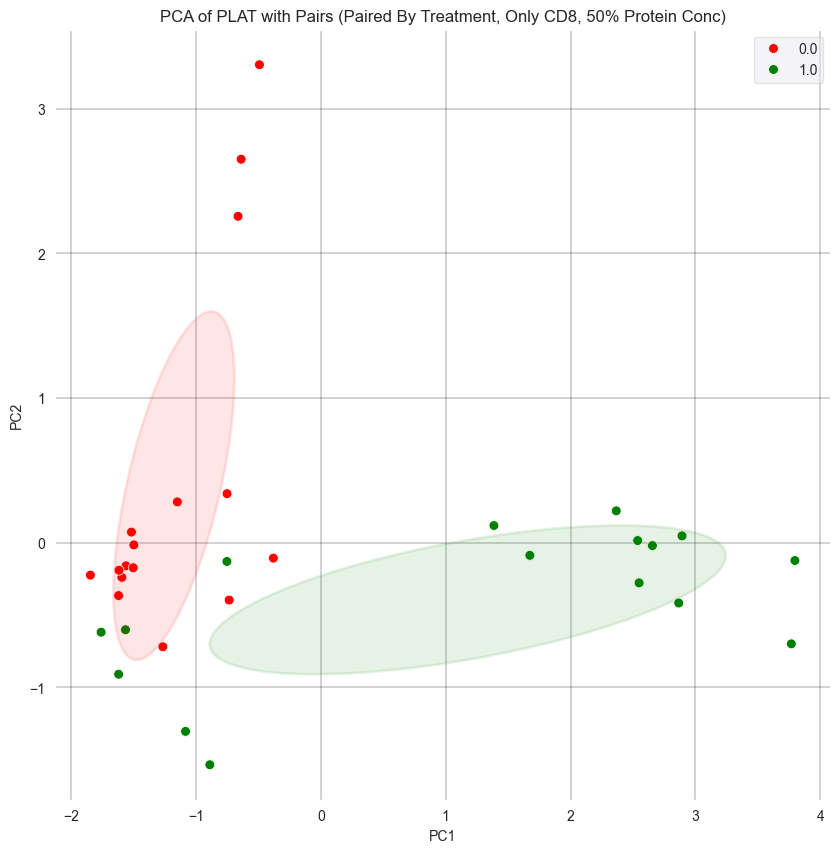

In [13]:
# Show CD8 Graph
cd8_df = paired_df.loc[cd8_index]

# get a the pair that exist in the CD8 index
cd8_pair_dict = {}
for key, value in pair_dict.items():
    if key in cd8_index and value in cd8_index:
        cd8_pair_dict[key] = value

plt = plot_pairs(cd8_df, cd8_pair_dict, target=TARGET,
           title="PCA of PLAT with Pairs (Paired By Treatment, Only CD8, 50% Protein Conc)",)

plt.savefig('output/PCA_prenormalized_CD8.svg', dpi=300)

# Pair Vector Centralization

In [14]:
from Step1Normalization import pair_normalizer_midpoint, pair_normalizer_log2fold, pair_normalizer_zero_control

normed_rows = []

for i, (key, value) in enumerate(pair_dict.items()):
    control_row = paired_df.loc[key]
    perturbed_row = paired_df.loc[value]

    transformed = pair_normalizer_zero_control(control_row, perturbed_row)
    normed_rows.append(transformed)

# Merge everything
paired_norm_df = pd.concat(normed_rows, axis=0)
paired_norm_df

,2A_BIRC3,BIRC3_BIRC3,FYB_BIRC3,LCK_BIRC3,NCK_BIRC3,PKCt_BIRC3,TRAF1_BIRC3,TRAF2_BIRC3,VAV1_BIRC3,2A_CD28,...,TRAF1_ZAP70,TRAF2_ZAP70,VAV1_ZAP70,ZAP70_ZAP70,cd4v8,protein conc,CRS,stim type,pair num,control
CAR_19_447,-9.499414,60.643485,16.960218,2.236230,7.205134,16.653537,-40.670511,-2.827491,16.044429,8.064157,...,5.061111,1.132791,-2.879090,-23.100227,4.0,1.740,1.0,19,0,0
CAR_19_452,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.0,1.680,0.0,19,0,0
CAR_19_474,5.427434,3.846624,2.925624,-1.888406,4.971299,1.515096,2.974317,0.229601,8.928811,-9.897056,...,5.677711,2.046888,-6.710738,-14.842007,4.0,3.391,1.0,19,1,0
CAR_19_411,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.0,3.600,0.0,19,1,0
CAR_N3_874_1,-12.538388,0.991425,-2.647236,4.065031,-4.677405,16.549386,-6.261341,6.418301,-2.487211,3.381040,...,7.540367,-3.205128,5.497651,143.899517,8.0,3.002,1.0,N3,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OR_US_3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.0,1.900,0.0,NaN,U3,0
CRS_US_4,1.045306,-2.868925,-1.922169,-0.554275,-1.278044,-6.189761,2.994708,3.733184,2.101398,-44.722020,...,-2.971317,-3.215021,5.120820,208.653684,4.0,2.000,1.0,NaN,U4,0
OR_US_4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.0,2.000,0.0,NaN,U4,0
CRS_US_5,6.041236,7.091789,10.061257,-4.016316,6.545511,-2.058339,-6.392292,-0.313622,15.150684,79.957809,...,3.106612,-0.803358,2.068715,-33.268856,4.0,2.000,1.0,NaN,U5,0


In [15]:
# take out the control for plotting because it just clutters the graph
SHOW_CONTROL_PAIR = True
if SHOW_CONTROL_PAIR:
    experimental_norm_pair_df = paired_norm_df
else:
    experimental_norm_pair_df = paired_norm_df[paired_norm_df['control'] == 0]


In [16]:
experimental_norm_pair_df

,2A_BIRC3,BIRC3_BIRC3,FYB_BIRC3,LCK_BIRC3,NCK_BIRC3,PKCt_BIRC3,TRAF1_BIRC3,TRAF2_BIRC3,VAV1_BIRC3,2A_CD28,...,TRAF1_ZAP70,TRAF2_ZAP70,VAV1_ZAP70,ZAP70_ZAP70,cd4v8,protein conc,CRS,stim type,pair num,control
CAR_19_447,-9.499414,60.643485,16.960218,2.236230,7.205134,16.653537,-40.670511,-2.827491,16.044429,8.064157,...,5.061111,1.132791,-2.879090,-23.100227,4.0,1.740,1.0,19,0,0
CAR_19_452,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.0,1.680,0.0,19,0,0
CAR_19_474,5.427434,3.846624,2.925624,-1.888406,4.971299,1.515096,2.974317,0.229601,8.928811,-9.897056,...,5.677711,2.046888,-6.710738,-14.842007,4.0,3.391,1.0,19,1,0
CAR_19_411,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.0,3.600,0.0,19,1,0
CAR_N3_874_1,-12.538388,0.991425,-2.647236,4.065031,-4.677405,16.549386,-6.261341,6.418301,-2.487211,3.381040,...,7.540367,-3.205128,5.497651,143.899517,8.0,3.002,1.0,N3,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OR_US_3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.0,1.900,0.0,NaN,U3,0
CRS_US_4,1.045306,-2.868925,-1.922169,-0.554275,-1.278044,-6.189761,2.994708,3.733184,2.101398,-44.722020,...,-2.971317,-3.215021,5.120820,208.653684,4.0,2.000,1.0,NaN,U4,0
OR_US_4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.0,2.000,0.0,NaN,U4,0
CRS_US_5,6.041236,7.091789,10.061257,-4.016316,6.545511,-2.058339,-6.392292,-0.313622,15.150684,79.957809,...,3.106612,-0.803358,2.068715,-33.268856,4.0,2.000,1.0,NaN,U5,0


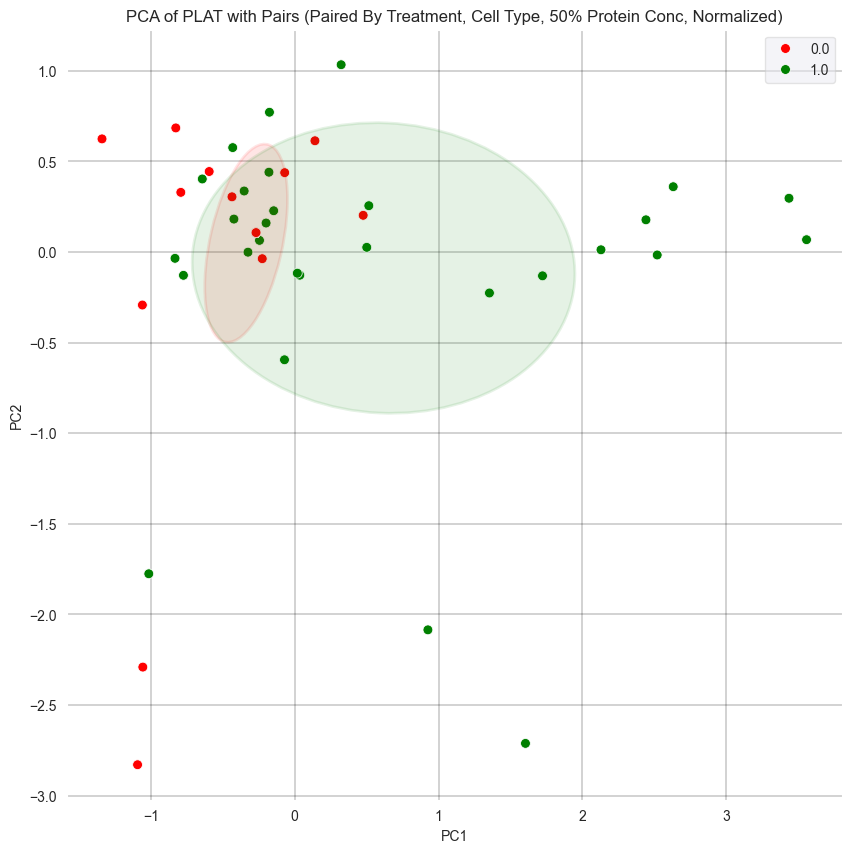

In [17]:
# run the PCA again
plt = plot_pairs(experimental_norm_pair_df,
           pair_dict,
           target=TARGET,
           title="PCA of PLAT with Pairs (Paired By Treatment, Cell Type, 50% Protein Conc, Normalized)",
           )

plt.savefig('output/PCA_normalized_all.svg', dpi=300)

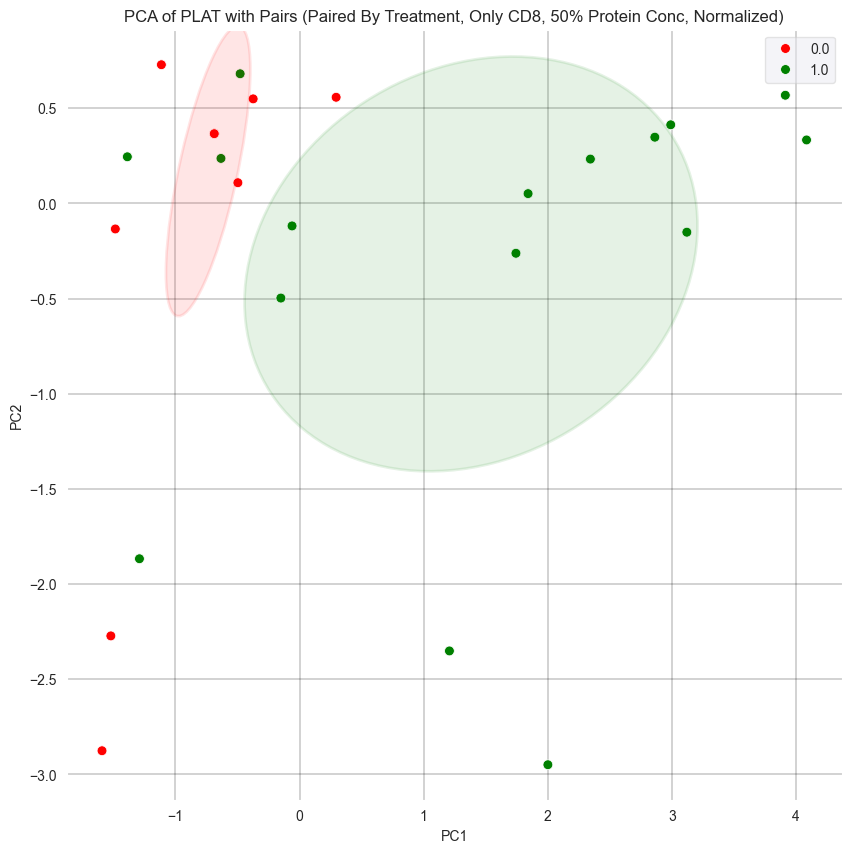

In [18]:
# Show CD8 Graph
cd8_df = experimental_norm_pair_df[experimental_norm_pair_df['cd4v8'] == 8]

# get a the pair that exist in the CD8 index
cd8_pair_dict = {}
for key, value in pair_dict.items():
    if key in cd8_index and value in cd8_index:
        cd8_pair_dict[key] = value

plt = plot_pairs(cd8_df, cd8_pair_dict, target=TARGET, title="PCA of PLAT with Pairs (Paired By Treatment, Only CD8, 50% Protein Conc, Normalized)")

plt.savefig('output/PCA_normalized_CD8.svg', dpi=300)

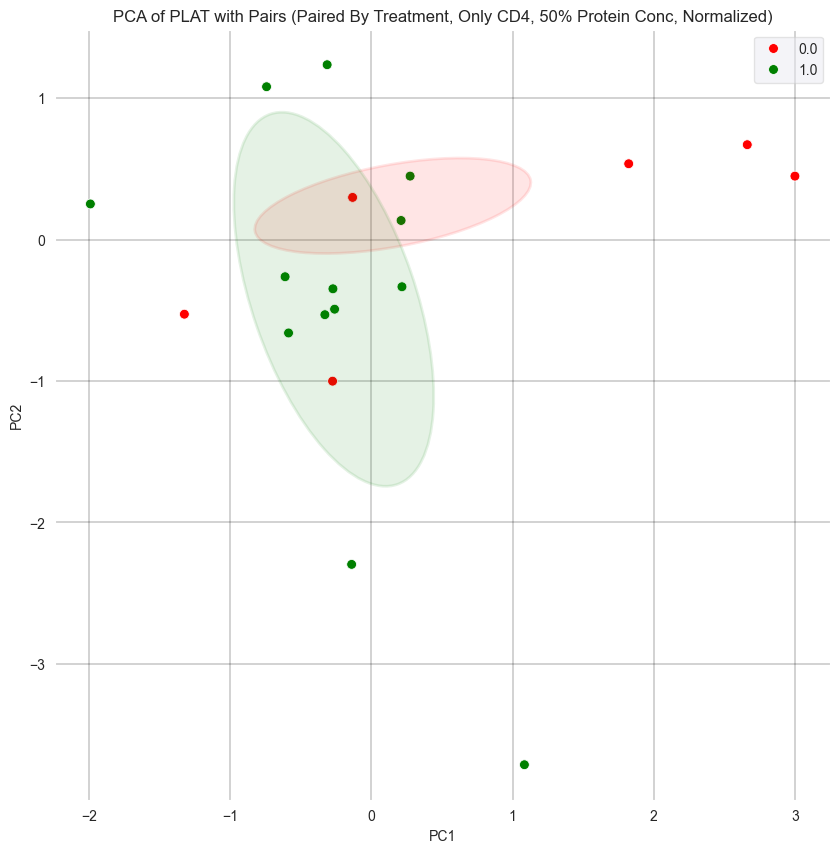

In [19]:
# Show CD4 Graph
cd4_df = experimental_norm_pair_df[experimental_norm_pair_df['cd4v8'] == 4]

# get a the pair that exist in the CD8 index
cd4_pair_dict = {}
for key, value in pair_dict.items():
    if key in cd4_index and value in cd4_index:
        cd4_pair_dict[key] = value

plt = plot_pairs(cd4_df, cd4_pair_dict, target=TARGET, title="PCA of PLAT with Pairs (Paired By Treatment, Only CD4, 50% Protein Conc, Normalized)")

plt.savefig('output/PCA_normalized_CD4.svg', dpi=300)

In [20]:
# save the paired_norm_df
paired_norm_df.to_csv('output/normalized_output.csv')